# 可选实验 - Softmax 函数
在本实验中，我们将探索softmax函数。该函数在Softmax回归和神经网络中解决多分类问题时都会使用。  

<center>  <img  src="./images/C2_W2_Softmax_Header.PNG" width="600" />  <center/>

  

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from IPython.display import display, Markdown, Latex
from sklearn.datasets import make_blobs
%matplotlib widget
from matplotlib.widgets import Slider
from lab_utils_common import dlc
from lab_utils_softmax import plt_softmax
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

I0000 00:00:1781450269.139060   47796 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781450269.175349   47796 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1781450270.350262   47796 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


> **注意**：通常在本课程中，笔记本使用从0开始到N-1结束的约定，$\sum_{i=0}^{N-1}$，而讲座从1开始到N结束，$\sum_{i=1}^{N}$。这是因为代码通常从0开始迭代，而在讲座中，从1到N计数会产生更简洁的方程。本笔记本比典型的实验有更多方程，因此将打破惯例，从1到N计数。

## Softmax 函数
在softmax回归和具有Softmax输出的神经网络中，都会生成N个输出，并选择一个输出作为预测类别。在这两种情况下，向量 $\mathbf{z}$ 由线性函数生成，然后应用于softmax函数。softmax函数将 $\mathbf{z}$ 转换为概率分布，如下所述。应用softmax后，每个输出将在0到1之间，输出之和为1，因此可以解释为概率。较大的输入将对应较大的输出概率。
<center>  <img  src="./images/C2_W2_SoftmaxReg_NN.png" width="600" />  

softmax函数可以写成：
$$a_j = \frac{e^{z_j}}{ \sum_{k=1}^{N}{e^{z_k} }} \tag{1}$$
输出 $\mathbf{a}$ 是一个长度为N的向量，因此对于softmax回归，你也可以写成：
\begin{align}
\mathbf{a}(x) =
\begin{bmatrix}
P(y = 1 | \mathbf{x}; \mathbf{w},b) \\
\vdots \\
P(y = N | \mathbf{x}; \mathbf{w},b)
\end{bmatrix}
=
\frac{1}{ \sum_{k=1}^{N}{e^{z_k} }}
\begin{bmatrix}
e^{z_1} \\
\vdots \\
e^{z_{N}} \\
\end{bmatrix} \tag{2}
\end{align}


这表明输出是一个概率向量。第一个条目是在给定输入 $\mathbf{x}$ 和参数 $\mathbf{w}$ 和 $\mathbf{b}$ 的情况下，输入属于第一个类别的概率。  
让我们创建一个NumPy实现：

In [2]:
def my_softmax(z):
    ez = np.exp(z)              #逐元素指数
    sm = ez/np.sum(ez)
    return(sm)

下面，使用滑块改变 `z` 输入的值。

/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 36755 (\N{CJK UNIFIED IDEOGRAPH-8F93}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')
/home/dev/gpu/.venv/lib/python3.13/site-packages/ipympl/backend_nbagg.py:392: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  self.figure.savefig(buf, format='png', dpi='figure')


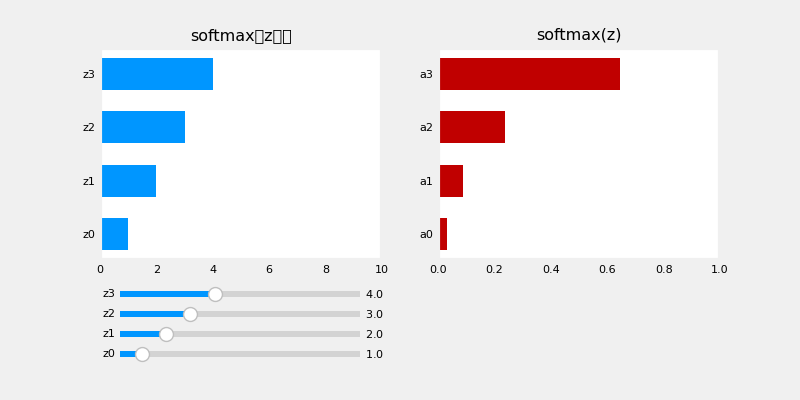

In [3]:
plt.close("all")
plt_softmax(my_softmax)

当你改变上面z的值时，有几点需要注意：
* softmax分子中的指数放大了值之间的微小差异 
* 输出值之和为1
* softmax跨越所有输出。例如，`z0` 的变化将改变 `a0`-`a3` 的值。将其与ReLU或Sigmoid等其他激活函数进行比较，后者是单输入单输出。

## 代价
<center> <img  src="./images/C2_W2_SoftMaxCost.png" width="400" />    <center/>

与Softmax相关的损失函数，即交叉熵损失为：
\begin{equation}
  L(\mathbf{a},y)=\begin{cases}
    -log(a_1), & \text{if $y=1$}.\\
        &\vdots\\
     -log(a_N), & \text{if $y=N$}
  \end{cases} \tag{3}
\end{equation}

其中y是此样本的目标类别，$\mathbf{a}$ 是softmax函数的输出。特别是，$\mathbf{a}$ 中的值是总和为1的概率。
>**回顾：** 在本课程中，Loss是针对一个样本的，而Cost涵盖所有样本。 
 
 
注意在上面的(3)中，只有对应于目标的那一行对损失有贡献，其他行为零。为了写出代价方程，我们需要一个'指示函数'，当索引匹配目标时为1，否则为零。 
    $$\mathbf{1}\{y == n\} = =\begin{cases}
    1, & \text{if $y==n$}.\\
    0, & \text{otherwise}.
  \end{cases}$$
现在代价为：
\begin{align}
J(\mathbf{w},b) = -\frac{1}{m} \left[ \sum_{i=1}^{m} \sum_{j=1}^{N}  1\left\{y^{(i)} == j\right\} \log \frac{e^{z^{(i)}_j}}{\sum_{k=1}^N e^{z^{(i)}_k} }\right] \tag{4}
\end{align}

其中 $m$ 是样本数，$N$ 是输出数。这是所有损失的平均值。


## Tensorflow
本实验将讨论在Tensorflow中实现softmax交叉熵损失的两种方法，'显而易见'的方法和'首选'方法。前者最直接，后者在数值上更稳定。

让我们从创建一个数据集来训练多分类模型开始。

In [4]:
# 创建示例数据集
centers = [[-5, 2], [-2, -2], [1, 2], [5, -2]]
X_train, y_train = make_blobs(n_samples=2000, centers=centers, cluster_std=1.0,random_state=30)

### *显而易见* 的组织方式

下面的模型将softmax作为最终Dense层中的激活函数来实现。
损失函数在 `compile` 指令中单独指定。 

损失函数是 `SparseCategoricalCrossentropy`。该损失在上面的(3)中描述。在此模型中，softmax在最后一层进行。损失函数接收softmax的输出，即概率向量。

In [5]:
model = Sequential(
    [ 
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(4, activation = 'softmax')    # < 这里使用softmax激活
    ]
)
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(0.001),
)

model.fit(
    X_train,y_train,
    epochs=10
)
        

W0000 00:00:1781450273.096343   47796 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.0546  
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3843  
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1803  
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step - loss: 0.1081
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0778  
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0621  
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0523  
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0461  
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0414  
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0384  


由于softmax集成在输出层中，输出是一个概率向量。

In [6]:
p_nonpreferred = model.predict(X_train)
print(p_nonpreferred [:2])
print("largest value", np.max(p_nonpreferred), "smallest value", np.min(p_nonpreferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[2.88e-03 4.62e-03 9.64e-01 2.81e-02]
 [9.95e-01 4.54e-03 1.82e-04 2.00e-05]]
largest value 0.99999917 smallest value 3.015416e-08


### 首选方式 <img align="Right" src="./images/C2_W2_softmax_accurate.png"  style=" width:400px; padding: 10px 20px ; ">
从讲座中回顾，如果在训练期间将softmax和损失组合在一起，可以获得更稳定和准确的结果。这通过这里显示的'首选'组织方式来实现。


在首选组织方式中，最后一层使用线性激活。由于历史原因，这种形式的输出被称为 *logits*。损失函数有一个额外的参数：`from_logits = True`。这通知损失函数softmax操作应包含在损失计算中。这允许进行优化实现。

In [7]:
preferred_model = Sequential(
    [ 
        Dense(25, activation = 'relu'),
        Dense(15, activation = 'relu'),
        Dense(4, activation = 'linear')   #<-- 注意
    ]
)
preferred_model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),  #<-- 注意
    optimizer=tf.keras.optimizers.Adam(0.001),
)

preferred_model.fit(
    X_train,y_train,
    epochs=10
)
        

Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.8763  
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.3217  
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1537  
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0956  
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0716  
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0600  
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0527  
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0478  
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0436  
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0410  


#### 输出处理
注意在首选模型中，输出不是概率，而是可以从大负数到大正数的范围。在执行需要概率的预测时，输出必须通过softmax处理。 
让我们看看首选模型的输出：

In [8]:
p_preferred = preferred_model.predict(X_train)
print(f"two example output vectors:\n {p_preferred[:2]}")
print("largest value", np.max(p_preferred), "smallest value", np.min(p_preferred))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step
two example output vectors:
 [[-0.26 -1.48  3.66 -0.44]
 [ 7.66  2.12 -1.78 -4.05]]
largest value 15.037515 smallest value -5.9137206


输出预测不是概率！
如果需要概率输出，应该通过 [softmax](https://www.tensorflow.org/api_docs/python/tf/nn/softmax) 处理输出。

In [9]:
sm_preferred = tf.nn.softmax(p_preferred).numpy()
print(f"two example output vectors:\n {sm_preferred[:2]}")
print("largest value", np.max(sm_preferred), "smallest value", np.min(sm_preferred))

two example output vectors:
 [[1.90e-02 5.59e-03 9.59e-01 1.59e-02]
 [9.96e-01 3.91e-03 7.90e-05 8.18e-06]]
largest value 0.9999963 smallest value 4.3228976e-09


要选择最可能的类别，不需要softmax。可以使用 [np.argmax()](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) 找到最大输出的索引。

In [10]:
for i in range(5):
    print( f"{p_preferred[i]}, category: {np.argmax(p_preferred[i])}")

[-0.26 -1.48  3.66 -0.44], category: 2
[ 7.66  2.12 -1.78 -4.05], category: 0
[ 5.73  1.95 -1.41 -3.41], category: 0
[-1.25  4.87 -1.02 -2.17], category: 1
[ 2.52 -3.51  7.37 -2.98], category: 2


## SparseCategorialCrossentropy 还是 CategoricalCrossEntropy
Tensorflow有两种潜在的目标值格式，损失函数的选择决定了期望的格式。
- SparseCategorialCrossentropy：期望目标是对应于索引的整数。例如，如果有10个潜在目标值，y将在0到9之间。 
- CategoricalCrossEntropy：期望样本的目标值是one-hot编码的，其中目标索引处的值为1，而其他N-1个条目为零。一个有10个潜在目标值的样本，如果目标是2，则为 [0,0,1,0,0,0,0,0,0,0]。


## 恭喜！
在本实验中你 
- 更熟悉了softmax函数及其在softmax回归和神经网络中softmax激活中的应用。 
- 学习了Tensorflow中的首选模型构建方式：
    - 最后一层不使用激活（等同于线性激活）
    - SparseCategoricalCrossentropy损失函数
    - 使用 from_logits=True
- 认识到与ReLU和Sigmoid不同，softmax跨越多个输出。